In [1]:
metrics = [
    "comet_kiwi",
    "comet_kiwi_23_xxl",
    "xcomet_qe_xxl",
    "metricx_qe_xxl",
]

In [2]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="1"

In [3]:
def read_file(fname):
    output = []
    with open(fname) as f:
        for line in f:
            output.append(line.strip())
    return output


In [4]:
from comet import download_model, load_from_checkpoint

# checkpoint_path = download_model("Unbabel/wmt22-cometkiwi-da")
checkpoint_path = download_model("Unbabel/XCOMET-XXL")
comet_metric = load_from_checkpoint(checkpoint_path)

/mnt/data-poseidon/sweta/explanations/explain/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/data-poseidon/sweta/explanations/explain/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
Lightning automatically upgraded your loaded checkpoint from v1.9.4 to v2.3.3. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../../../../scratch-artemis/sweta/cache/models--Unbabel--XCOMET-XXL/snapshots/bad20b47daa64c41a8b29f3d3016be75baf0d7b4/checkpoints/model.ckpt`
/mnt/data-poseidon/sweta/explanations/explain/lib/python3.10/site-packages/pytorch_lightning/core/saving.py:195: Found keys that are not in the

In [5]:
def get_translations(df, lp, context_type, model_name, split="test"):
  source_lang = lp.split("-")[0]
  target_lang = lp.split("-")[1].replace('pt','pt-br')

  xx_yy_generations = read_file(f"generations/{context_type}/mt/wmt24_chat_{split.replace('test', 'test_blind')}.{source_lang}-{target_lang}/vllm/{model_name}/generation.txt")
  yy_xx_generations = read_file(f"generations/{context_type}/mt/wmt24_chat_{split.replace('test', 'test_blind')}.{target_lang}-{source_lang}/vllm/{model_name}/generation.txt")

  assert len(xx_yy_generations) + len(yy_xx_generations) == len(df)
  translations = []
  j,k=0,0

  for i, row in df.iterrows():
    if row["lp"] == f"{source_lang}-{target_lang}":
      translations.append(xx_yy_generations[j])
      j+=1
    else:
      # nl-en and it-en are considered here
      translations.append(yy_xx_generations[k])
      k+=1
  return translations

In [7]:
import pandas as pd

for lang in ["de", "pt", "ko", "nl", "fr"]:
    df = pd.read_csv(f"/mnt/data-poseidon/sweta/chat-translation-generation/wmt24-chat-translation/chat-task-2024-data/test/en-{lang}.csv")
    df["lp"] = df["source_language"] + "-" + df["target_language"]
    # df = pd.read_csv(f"analysis/test.en-{lang}.csv")

    fnames = {
        "greedy-7b": get_translations(df, "en-" + lang, "full_context_empty_sys", "TowerInstruct-7B-w-chat-empty-sys"),
        "greedy-70b-5shot": get_translations(df, "en-" + lang, "full_context_empty_sys_llama3_5_shot", "Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy"),
        "mbr": read_file(f"/mnt/data-poseidon/sweta/chat-translation-generation/wmt24-chat-translation/mbr_outputs_test/full_context_empty_sys/wmt24_chat_test.en-{lang}/comet_eps.out.txt"),
        "mbr-hyp": read_file(f"/mnt/data-poseidon/sweta/chat-translation-generation/wmt24-chat-translation/mbr_outputs_test/full_context_empty_sys/wmt24_chat_test.en-{lang}/comet_eps_context_hyp.out.txt"),
        "mbr-source": read_file(f"/mnt/data-poseidon/sweta/chat-translation-generation/wmt24-chat-translation/mbr_outputs_test/full_context_empty_sys/wmt24_chat_test.en-{lang}/comet_eps_context_source.out.txt"),
        "mbr-across": read_file(f"/mnt/data-poseidon/sweta/chat-translation-generation/wmt24-chat-translation/mbr_outputs_test/full_context_empty_sys/wmt24_chat_test.en-{lang}/comet_eps_context_source_across.out.txt"),

    }

    for mname, file_path in fnames.items():
        df[f"{mname}-comet_kiwi"] = comet_metric.predict([{"mt": y,  "src": x} for x, y in zip(df["source"].to_list(), fnames[mname] )], 
            batch_size=16, gpus=1, progress_bar=True, devices=[0])['scores']
    df.to_csv(f"analysis/test.en-{lang}.csv", index=None)

/mnt/data-poseidon/sweta/explanations/explain/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /mnt/data-poseidon/sweta/explanations/explain/lib/py ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [1]
Predicting DataLoader 0: 100%|██████████| 128/128 [01:36<00:00,  1.32it/s]
/mnt/data-poseidon/sweta/explanations/explain/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /mnt/data-poseidon/sweta/explanations/explain/lib/py ...
GPU available: True (cuda), used: True
TP

In [48]:
def write_to_file(fname, my_list):
    with open(fname, 'w') as file:
        # Write each element of the list to the file
        for item in my_list:
            file.write(f"{item}\n")

scores_list = []
for lang in ["de", "pt", "ko", "nl", "fr"]:
    df = pd.read_csv(f"analysis/test.en-{lang}.csv")
    fnames = {
        "greedy-7b": get_translations(df, "en-" + lang, "full_context_empty_sys", "TowerInstruct-7B-w-chat-empty-sys"),
        "greedy-70b-5shot": get_translations(df, "en-" + lang, "full_context_empty_sys_llama3_5_shot", "Tower-CPT-2106-WMT24-70B-SFT-Merge-greedy"),
        "mbr": read_file(f"/mnt/data-poseidon/sweta/chat-translation-generation/wmt24-chat-translation/mbr_outputs_test/full_context_empty_sys/wmt24_chat_test.en-{lang}/comet_eps.out.txt"),
        "mbr-hyp": read_file(f"/mnt/data-poseidon/sweta/chat-translation-generation/wmt24-chat-translation/mbr_outputs_test/full_context_empty_sys/wmt24_chat_test.en-{lang}/comet_eps_context_hyp.out.txt"),
        "mbr-source": read_file(f"/mnt/data-poseidon/sweta/chat-translation-generation/wmt24-chat-translation/mbr_outputs_test/full_context_empty_sys/wmt24_chat_test.en-{lang}/comet_eps_context_source.out.txt"),
        "mbr-across": read_file(f"/mnt/data-poseidon/sweta/chat-translation-generation/wmt24-chat-translation/mbr_outputs_test/full_context_empty_sys/wmt24_chat_test.en-{lang}/comet_eps_context_source_across.out.txt"),

    }

    os.makedirs(f'submission_unbabel+it/en-{lang}', exist_ok=True)
    write_to_file(f'submission_unbabel+it/en-{lang}/primary.txt', fnames["mbr-source"])
    write_to_file(f'submission_unbabel+it/en-{lang}/contrastive1.txt', fnames["greedy-70b-5shot"])
    write_to_file(f'submission_unbabel+it/en-{lang}/contrastive2.txt', fnames["greedy-7b"])

    for mname in fnames.keys():
        for lp, lp_df in df.groupby("lp"):
            scores_list.append([lp, mname, lp_df[f"{mname}-comet_kiwi"].mean()])
            # scores_list.append([lp, mname, lp_df[f"{mname}-xcomet_qe_xxl"].mean(), lp_df[f"{mname}-comet_kiwi"].mean()])

In [49]:
scores_df = pd.DataFrame(scores_list)
scores_df.columns = ["LP", "Model", "Xcomet-xxl"]

In [50]:
scores_df["lp-type"] = scores_df["LP"].apply(lambda x: "en-xx" if x.split("-")[0]=="en" else "xx-en")

In [51]:
for gr_name, gr_df in scores_df.groupby(["Model", "lp-type"]):
    print(gr_name, gr_df["Xcomet-xxl"].mean())

('greedy-70b-5shot', 'en-xx') 0.9740917502467574
('greedy-70b-5shot', 'xx-en') 0.9474417432501708
('greedy-7b', 'en-xx') 0.9683351082233205
('greedy-7b', 'xx-en') 0.9483678429220536
('mbr', 'en-xx') 0.9729930114370913
('mbr', 'xx-en') 0.9519698372800012
('mbr-across', 'en-xx') 0.9730064310485547
('mbr-across', 'xx-en') 0.9515322696404714
('mbr-hyp', 'en-xx') 0.9728376878374909
('mbr-hyp', 'xx-en') 0.9515182032530479
('mbr-source', 'en-xx') 0.9726323026225717
('mbr-source', 'xx-en') 0.9516942031258837


In [11]:
scores_df.sort_values(["LP", "Model"])

,LP,Model,comet_kiwi
2,de-en,greedy-70b-5shot,0.953465
0,de-en,greedy-7b,0.957395
4,de-en,mbr,0.960229
10,de-en,mbr-across,0.961023
6,de-en,mbr-hyp,0.960831
8,de-en,mbr-source,0.961578
3,en-de,greedy-70b-5shot,0.989364
1,en-de,greedy-7b,0.986293
5,en-de,mbr,0.988144
11,en-de,mbr-across,0.988477


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

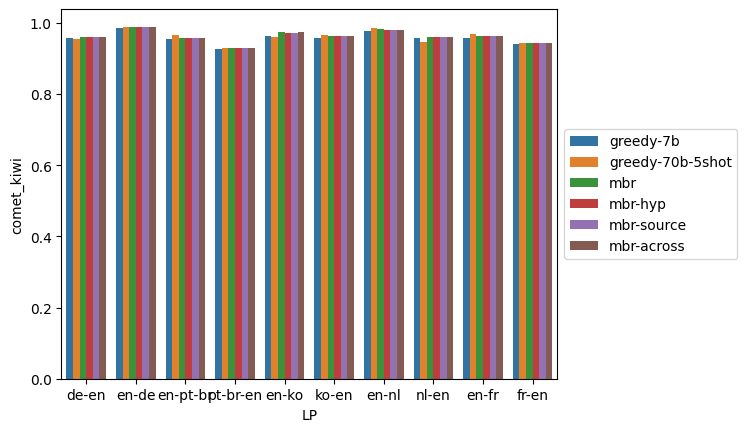

In [13]:
sns.barplot(scores_df, hue="Model", x="LP", y="comet_kiwi")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

## Dev results

In [34]:
import glob

def read_score(fname):
    scores = []
    with open(fname) as f:
        for line in f:
            scores.append(float(line.split(": ")[1]))
    if "en-de" in fname:
        scores = scores[2:] + scores[:2]
    return scores

scores_list = []
for dir in glob.glob("/mnt/data-poseidon/sweta/chat-translation-generation/wmt24-chat-translation/mbr_outputs_dev/full_context_empty_sys/*"):
    for lp in glob.glob(dir + "/*.score.txt"):
        comet_en_xx, chrf_en_xx, comet_xx_en, chrf_xx_en=  read_score(lp)
        scores_list.append([dir.split("/")[-1], lp.split("/")[-1]] +  [ "en-xx", comet_en_xx, chrf_en_xx])
        scores_list.append([dir.split("/")[-1], lp.split("/")[-1]] +  [ "xx-en", comet_xx_en, chrf_xx_en])

In [35]:
scores_df = pd.DataFrame(scores_list)
scores_df.columns = ["LP", "Model", "lp-type", "comet", "chrf"]

In [37]:
for gr_name, gr_df in scores_df.groupby(["Model"]):
    print(gr_name, gr_df["chrf"].mean())

('comet_eps.score.txt',) 74.26955331501225
('comet_eps_context_hyp.score.txt',) 75.87792351605367
('comet_eps_context_source.score.txt',) 75.96380386545783
('comet_eps_context_source_across.score.txt',) 75.96001343920543


In [38]:
for gr_name, gr_df in scores_df.groupby(["Model"]):
    print(gr_name, gr_df["comet"].mean())

('comet_eps.score.txt',) 0.9133806993908777
('comet_eps_context_hyp.score.txt',) 0.9251177936034752
('comet_eps_context_source.score.txt',) 0.9250458795625391
('comet_eps_context_source_across.score.txt',) 0.9252408180637722
